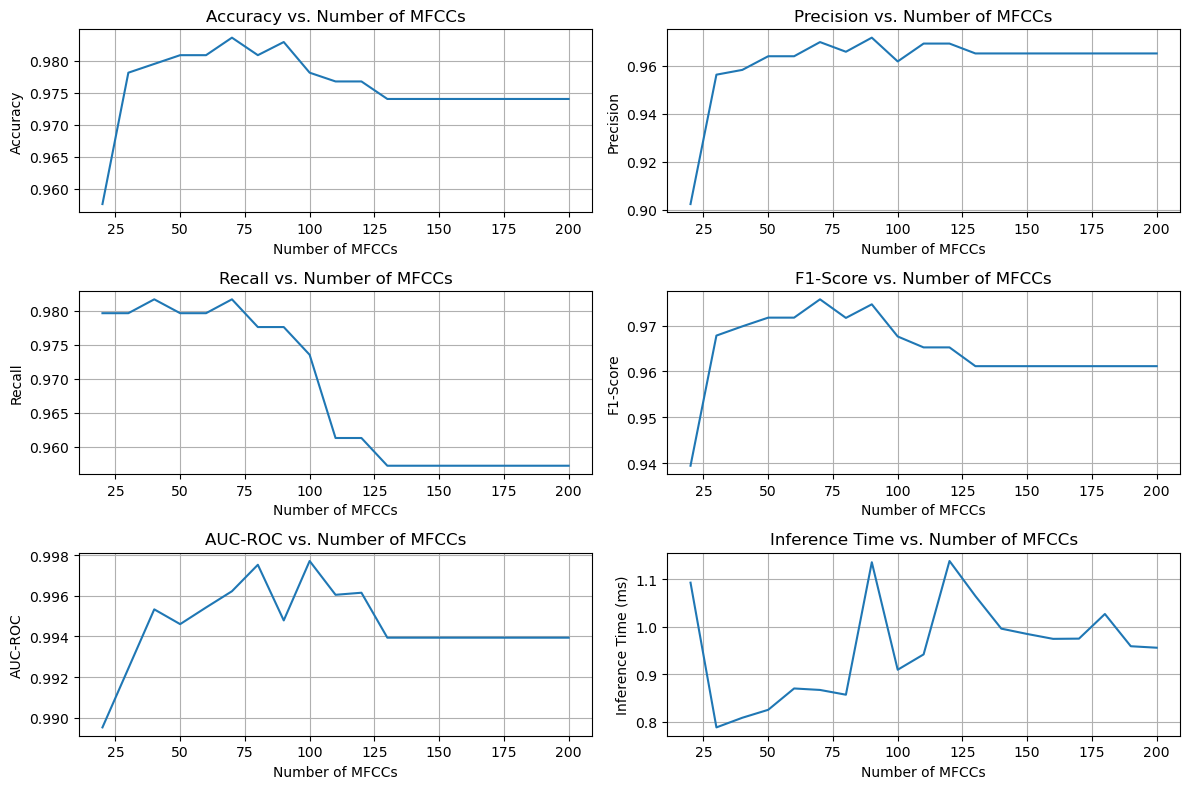

In [2]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

# Function to extract MFCCs from audio files
def extract_mfccs(file_path, n_mfcc=40):  # Added n_mfcc as a parameter
    try:
        y, sr = librosa.load(file_path, duration=1)  # Load 1-second audio
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfccs.T, axis=0)  # Average MFCCs over time
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Data Loading and Feature Extraction
male_folder = "/home/feliciano/adult_lobsters"  # Replace with your actual male folder name if different
female_folder = "/home/feliciano/juvenile_lobsters"  # Replace with your actual female folder name if different

# Range of MFCCs to test
n_mfcc_values = range(20, 201, 10)  # Test MFCCs from 20 to 200 (inclusive) in steps of 10

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_roc_scores = []
inference_times = []

for n_mfcc in n_mfcc_values:
    data = []
    labels = []

    for filename in os.listdir(male_folder):
        file_path = os.path.join(male_folder, filename)
        if os.path.isfile(file_path) and filename.endswith(('.wav', '.mp3', '.ogg', '.flac')):
            mfccs = extract_mfccs(file_path, n_mfcc=n_mfcc)  # Pass n_mfcc
            if mfccs is not None:
                data.append(mfccs)
                labels.append("adult")

    for filename in os.listdir(female_folder):
        file_path = os.path.join(female_folder, filename)
        if os.path.isfile(file_path) and filename.endswith(('.wav', '.mp3', '.ogg', '.flac')):
            mfccs = extract_mfccs(file_path, n_mfcc=n_mfcc)  # Pass n_mfcc
            if mfccs is not None:
                data.append(mfccs)
                labels.append("juvenile")

    if not data:
        print("No audio files found in the specified folders.")
        continue  # Skip to the next MFCC value

    X = np.array(data)
    y = np.array(labels)

    # Label Encoding and Data Scaling
    le = LabelEncoder()
    y = le.fit_transform(y)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # KNN Model
    knn_model = KNeighborsClassifier()

    # Model Training and Evaluation
    start_time = time.time()
    knn_model.fit(X_train, y_train)
    end_time = time.time()
    inference_time = (end_time - start_time) * 1000  # milliseconds

    y_pred = knn_model.predict(X_test)
    y_pred_proba = knn_model.predict_proba(X_test)[:, 1]  # Probability of the positive class

    # Calculate Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)

    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    auc_roc_scores.append(auc_roc)
    inference_times.append(inference_time)

# Plotting the Metrics
plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1)
plt.plot(n_mfcc_values, accuracy_scores, marker='')
plt.title('Accuracy vs. Number of MFCCs')
plt.xlabel('Number of MFCCs')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(n_mfcc_values, precision_scores, marker='')
plt.title('Precision vs. Number of MFCCs')
plt.xlabel('Number of MFCCs')
plt.ylabel('Precision')
plt.grid(True)

plt.subplot(3, 2, 3)
plt.plot(n_mfcc_values, recall_scores, marker='')
plt.title('Recall vs. Number of MFCCs')
plt.xlabel('Number of MFCCs')
plt.ylabel('Recall')
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(n_mfcc_values, f1_scores, marker='')
plt.title('F1-Score vs. Number of MFCCs')
plt.xlabel('Number of MFCCs')
plt.ylabel('F1-Score')
plt.grid(True)

plt.subplot(3, 2, 5)
plt.plot(n_mfcc_values, auc_roc_scores, marker='')
plt.title('AUC-ROC vs. Number of MFCCs')
plt.xlabel('Number of MFCCs')
plt.ylabel('AUC-ROC')
plt.grid(True)

plt.subplot(3, 2, 6)
plt.plot(n_mfcc_values, inference_times, marker='')
plt.title('Inference Time vs. Number of MFCCs')
plt.xlabel('Number of MFCCs')
plt.ylabel('Inference Time (ms)')
plt.grid(True)

plt.tight_layout()
plt.show()